# Hyperspectral Image Classification — Colab Notebook
**Authors:** Gaurav Gali & BS Hariesh  
**Goals:** preprocess HSI, visualize spectra & images, reduce dimensionality, train & evaluate RF, SVM, LR, KNN, XGBoost, produce visually rich outputs.


In [ ]:
!pip install numpy scipy matplotlib scikit-learn xgboost spectral umap-learn opencv-python-headless wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=75d4e0cfd2116aa52203a33ad1166479f8276a6db38994541b7e6127727c730c
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [ ]:
!pip install numpy scipy matplotlib scikit-learn xgboost umap-learn opencv-python-headless joblib


In [ ]:
import os, urllib.request, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import umap
import cv2
import joblib

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

# Create folder for datasets and outputs
os.makedirs("datasets", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


In [ ]:
DATASET_MIRRORS = {
    "indian_pines": [
        "https://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat",
        "https://www.ehu.eus/ccwintco/uploads/2/22/Indian_pines_corrected.mat",
        "https://ndownloader.figshare.com/files/25527804"
    ],
    "indian_pines_gt": [
        "https://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat",
        "https://ndownloader.figshare.com/files/25527807"
    ],
    "paviaU": [
        "https://www.ehu.eus/ccwintco/uploads/e/ee/PaviaU.mat",
        "https://figshare.com/ndownloader/files/XXXXX"
    ],
    "paviaU_gt": [
        "https://www.ehu.eus/ccwintco/uploads/5/50/PaviaU_gt.mat"
    ],
    "salinas": [
        "https://www.ehu.eus/ccwintco/uploads/a/a3/Salinas_corrected.mat",
        "https://www.ehu.eus/ccwintco/uploads/f/f1/Salinas_corrected.mat",
        "https://zenodo.org/record/15771735/files/Salinas_corrected.mat"
    ],
    "salinas_gt": [
        "https://www.ehu.eus/ccwintco/uploads/f/fa/Salinas_gt.mat",
        "https://zenodo.org/record/15771735/files/Salinas_gt.mat"
    ]
}

def try_download(urls, dest_path, timeout=20):
    """Try multiple URLs until one downloads successfully."""
    if os.path.exists(dest_path):
        print(f"[skip] already exists: {dest_path}")
        return dest_path
    last_err = None
    for url in urls:
        try:
            print(f"Attempting download: {url}")
            urllib.request.urlretrieve(url, dest_path)
            print(f"Downloaded → {dest_path}")
            return dest_path
        except Exception as e:
            last_err = e
            print(f"Failed: {url}  — {repr(e)}")

    raise RuntimeError(f"All mirrors failed for {dest_path}. Last error: {repr(last_err)}")


In [ ]:
# Cell 3 — Choose dataset to run (options: 'indian_pines', 'paviaU', 'salinas')
# You can run the notebook multiple times with different dataset variable.
dataset_choice = "indian_pines"   # options: 'indian_pines', 'paviaU', 'salinas'
print("Dataset selected:", dataset_choice)

# Map dataset_choice to the appropriate data+gt entries
if dataset_choice == "indian_pines":
    data_urls = DATASET_MIRRORS["indian_pines"]
    gt_urls   = DATASET_MIRRORS["indian_pines_gt"]
    data_path = "datasets/Indian_pines_corrected.mat"
    gt_path   = "datasets/Indian_pines_gt.mat"
elif dataset_choice == "paviaU":
    data_urls = DATASET_MIRRORS["paviaU"]
    gt_urls   = DATASET_MIRRORS["paviaU_gt"]
    data_path = "datasets/PaviaU.mat"
    gt_path   = "datasets/PaviaU_gt.mat"
elif dataset_choice == "salinas":
    data_urls = DATASET_MIRRORS["salinas"]
    gt_urls   = DATASET_MIRRORS["salinas_gt"]
    data_path = "datasets/Salinas_corrected.mat"
    gt_path   = "datasets/Salinas_gt.mat"
else:
    raise ValueError("Unsupported dataset_choice. Choose 'indian_pines', 'paviaU', or 'salinas'")

# Download using robust try_download
try:
    try_download(data_urls, data_path)
    try_download(gt_urls, gt_path)
except RuntimeError as e:
    print("Download failed for all mirrors. As a fallback you can:")
    raise


Dataset selected: indian_pines
[skip] already exists: datasets/Indian_pines_corrected.mat
[skip] already exists: datasets/Indian_pines_gt.mat


In [ ]:
# Cell 4 — Load .mat and extract HxWxB and GT arrays robustly
def load_hsi_and_gt(mat_path, gt_path):
    d = loadmat(mat_path)
    g = loadmat(gt_path)
    # Heuristic: pick first 3D array from mat dict for image, first 2D array for GT
    X = None; y = None
    for k,v in d.items():
        if isinstance(v, np.ndarray) and v.ndim == 3:
            X = v
            break
    for k,v in g.items():
        if isinstance(v, np.ndarray) and v.ndim == 2:
            y = v
            break
    if X is None:
        for name in ['indian_pines_corrected', 'indian_pines', 'salinas_corrected', 'paviaU', 'PaviaU']:
            if name in d:
                X = d[name]
                break
    if y is None:
        for name in ['indian_pines_gt', 'salinas_gt', 'PaviaU_gt', 'pavia_gt', 'Pavia_gt']:
            if name in g:
                y = g[name]
                break
    if X is None or y is None:
        print("MAT file keys (image):", [k for k in d.keys() if not k.startswith('__')])
        print("MAT file keys (gt):", [k for k in g.keys() if not k.startswith('__')])
        raise RuntimeError("Could not automatically find image or gt arrays in .mat file. Inspect keys above.")
    return X.astype(np.float32), y.astype(int)

X, y = load_hsi_and_gt(data_path, gt_path)
print("Loaded X shape:", X.shape, "GT shape:", y.shape)
H, W, B = X.shape


Loaded X shape: (145, 145, 200) GT shape: (145, 145)


In [ ]:
# Cell 5 — Visual helper functions
def plot_false_color(X, bands=(50,30,15), title="False-color composite"):
    H,W,B = X.shape
    b = [min(max(0,bi), B-1) for bi in bands]
    rgb = np.stack([X[:,:,b[0]], X[:,:,b[1]], X[:,:,b[2]]], axis=-1)
    # Normalize per channel for display
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-9)
    plt.figure(figsize=(6,6))
    plt.imshow(rgb)
    plt.axis('off')
    plt.title(title)
    plt.show()

def flatten_and_mask(X, y):
    H,W,B = X.shape
    X2 = X.reshape(-1, B)
    y2 = y.reshape(-1)
    mask = y2 > 0
    return X2, y2, mask

def plot_pca_variance(pca):
    plt.figure(figsize=(6,4))
    plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker='o')
    plt.xlabel('Number of components')
    plt.ylabel('Cumulative explained variance (%)')
    plt.title('PCA explained variance')
    plt.grid(True)
    plt.show()


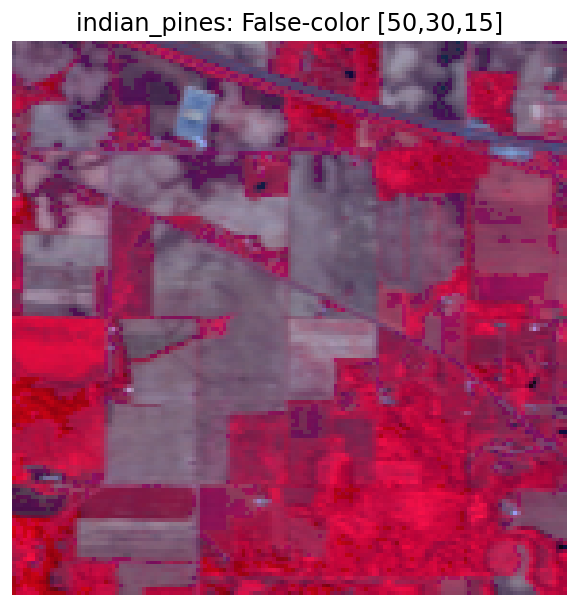

In [ ]:
# Cell 6 — Quick false-color to inspect scene (pick reasonable bands)
try:
    plot_false_color(X, bands=(50,30,15), title=f"{dataset_choice}: False-color [50,30,15]")
except:
    plot_false_color(X, bands=(30,20,10), title=f"{dataset_choice}: False-color [30,20,10]")


In [ ]:
# Cell 7 — Preprocess: flatten, mask labeled pixels, optional bilateral filtering, standardize
X_all, y_all, mask = flatten_and_mask(X, y)
X_labeled = X_all[mask]
y_labeled = y_all[mask]
print("Total pixels:", X_all.shape[0], "Labeled pixels:", X_labeled.shape[0], "bands:", X_labeled.shape[1])
y_labeled -= y_labeled.min()

# Optional bilateral smoothing (set to False for speed)
apply_bilateral = False
if apply_bilateral:
    print("Applying bilateral filter band-wise (slow)...")
    X_filtered = np.zeros_like(X)
    for b in range(B):
        band = X[:,:,b]
        # normalize band to 0..255 for cv2
        band_n = (255*((band - band.min())/(band.ptp()+1e-9))).astype('uint8')
        filt = cv2.bilateralFilter(band_n, d=5, sigmaColor=30, sigmaSpace=5)
        X_filtered[:,:,b] = filt.astype(np.float32)/255.0
    X_labeled = X_filtered.reshape(-1, B)[mask]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_labeled)


Total pixels: 21025 Labeled pixels: 10249 bands: 200


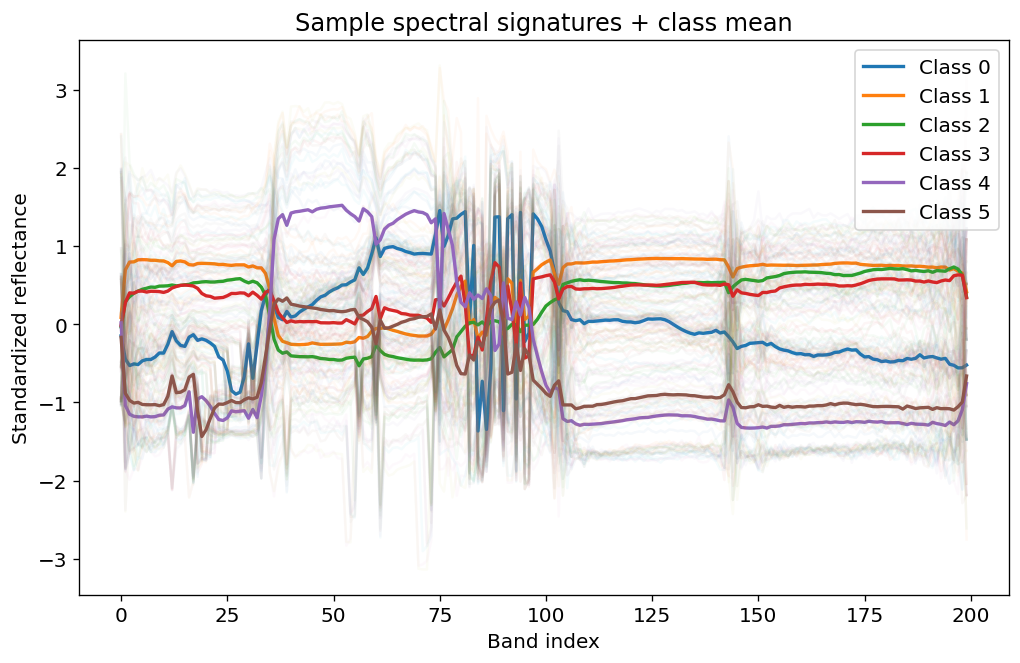

In [ ]:
# Cell 8 — Plot spectral signatures for first few classes (visual quality)
def plot_spectral_samples(X_scaled, y_labeled, classes_to_plot=None, samples_per_class=30):
    bands = np.arange(X_scaled.shape[1])
    if classes_to_plot is None:
        classes_to_plot = np.unique(y_labeled)[:6]
    plt.figure(figsize=(10,6))
    for c in classes_to_plot:
        idxs = np.where(y_labeled == c)[0]
        if idxs.size == 0:
            continue
        sel = np.random.choice(idxs, min(samples_per_class, idxs.size), replace=False)
        for s in sel:
            plt.plot(bands, X_scaled[s], alpha=0.04)
        plt.plot(bands, X_scaled[idxs].mean(axis=0), linewidth=2, label=f"Class {c}")
    plt.xlabel("Band index")
    plt.ylabel("Standardized reflectance")
    plt.legend()
    plt.title("Sample spectral signatures + class mean")
    plt.show()

plot_spectral_samples(X_scaled, y_labeled, classes_to_plot=np.unique(y_labeled)[:6])


PCA shape: (10249, 30)


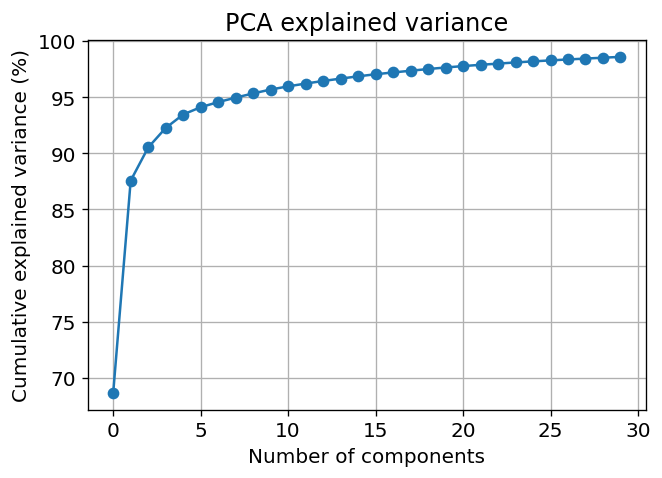

In [ ]:
# Cell 9 — PCA (Principle Component Analysis) (dimensionality reduction) + variance plot
n_pca = 30
pca = PCA(n_components=n_pca, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("PCA shape:", X_pca.shape)
plot_pca_variance(pca)


Computing UMAP (this may take ~30s for large labeled sets)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


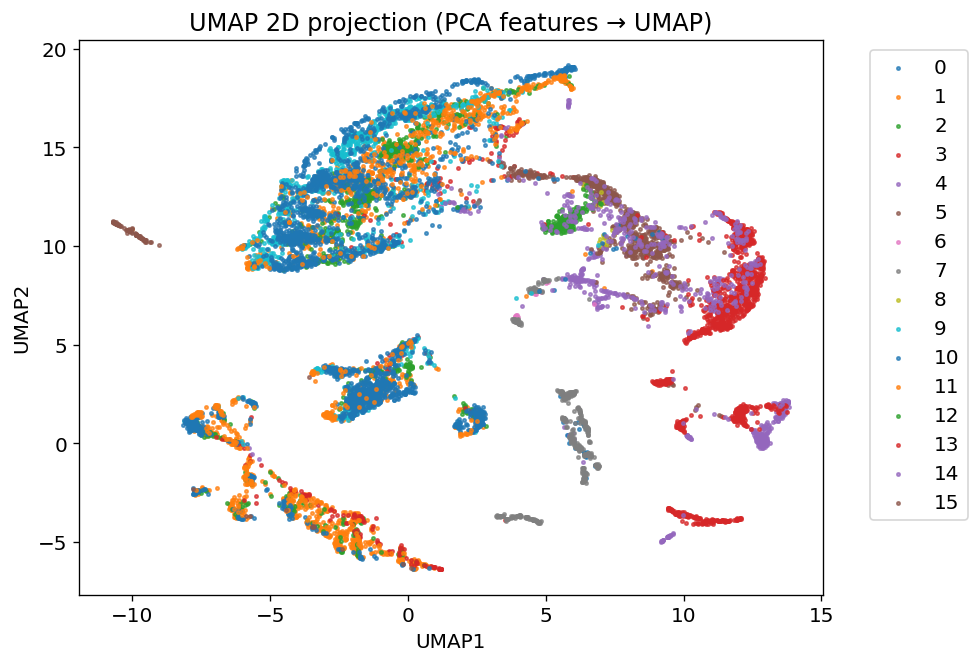

In [ ]:
# Cell 10 — UMAP 2D embedding for visualization (fast, adjust n_neighbors/min_dist if needed)
print("Computing UMAP (this may take ~30s for large labeled sets)...")
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.3, random_state=42)
emb = reducer.fit_transform(X_pca)
plt.figure(figsize=(8,6))
for cls in np.unique(y_labeled):
    idx = y_labeled == cls
    plt.scatter(emb[idx,0], emb[idx,1], s=4, alpha=0.7, label=str(cls))
plt.legend(bbox_to_anchor=(1.05,1))
plt.title("UMAP 2D projection (PCA features → UMAP)")
plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.show()


In [ ]:
# Cell 11 — Train/test split (stratified) and model definitions
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_labeled, test_size=0.2, stratify=y_labeled, random_state=42)
print("Train:", X_train.shape[0], "Test:", X_test.shape[0])

models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=2000, solver='saga', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=4)
}
results = {}
trained = {}


Train: 8199 Test: 2050


In [ ]:
# Cell 12 — Train all models and collect accuracy (print progress)
for name, clf in models.items():
    print(f"\nTraining {name} ...")
    t0 = time.time()
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    t1 = time.time()
    print(f"{name} accuracy: {acc:.4f}   (time: {t1-t0:.1f}s)")
    results[name] = acc
    trained[name] = clf



Training RandomForest ...
RandomForest accuracy: 0.8059   (time: 25.7s)

Training SVM ...
SVM accuracy: 0.7815   (time: 18.5s)

Training LogisticRegression ...
LogisticRegression accuracy: 0.7478   (time: 38.1s)

Training KNN ...
KNN accuracy: 0.7512   (time: 0.2s)

Training XGBoost ...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:16:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost accuracy: 0.8239   (time: 13.4s)


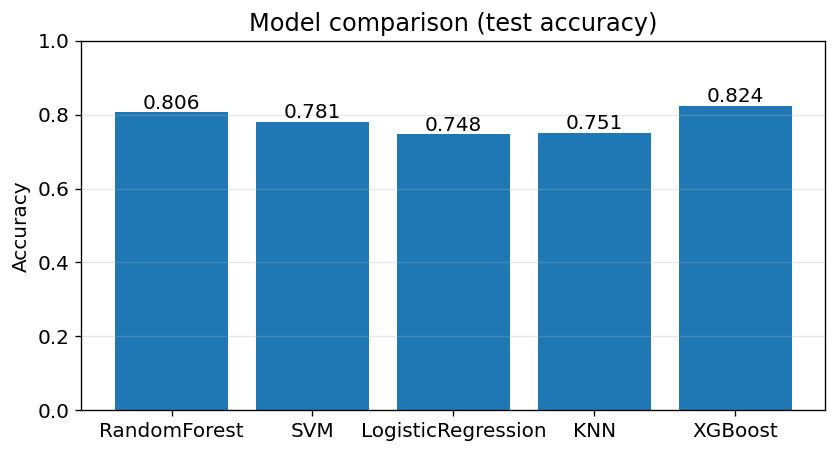

In [ ]:
# Cell 13 — Accuracy bar chart
plt.figure(figsize=(8,4))
names = list(results.keys()); accs = [results[n] for n in names]
plt.bar(names, accs)
plt.ylim(0,1)
plt.title("Model comparison (test accuracy)")
plt.ylabel("Accuracy")
for i,v in enumerate(accs):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center')
plt.grid(axis='y', alpha=0.3)
plt.show()


Best model: XGBoost


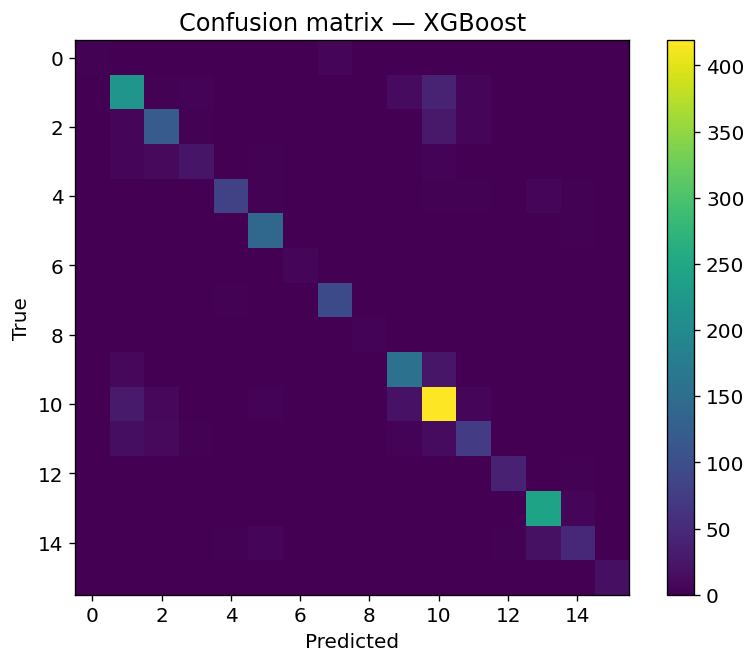

Classification report (best model):
              precision    recall  f1-score   support

           0     1.0000    0.3333    0.5000         9
           1     0.7569    0.7622    0.7596       286
           2     0.7806    0.7289    0.7539       166
           3     0.7059    0.5106    0.5926        47
           4     0.9318    0.8454    0.8865        97
           5     0.9045    0.9726    0.9373       146
           6     1.0000    1.0000    1.0000         5
           7     0.9307    0.9792    0.9543        96
           8     0.8000    1.0000    0.8889         4
           9     0.7970    0.8093    0.8031       194
          10     0.7846    0.8534    0.8176       491
          11     0.7872    0.6218    0.6948       119
          12     0.9286    0.9512    0.9398        41
          13     0.9101    0.9605    0.9346       253
          14     0.7541    0.5974    0.6667        77
          15     0.9474    0.9474    0.9474        19

    accuracy                         0.8239 

In [ ]:
# Cell 14 — Confusion matrix + classification report for best model
best_name = max(results, key=results.get)
best_model = trained[best_name]
print("Best model:", best_name)
pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, pred_best)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='viridis')
plt.colorbar()
plt.title(f"Confusion matrix — {best_name}")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

print("Classification report (best model):")
print(classification_report(y_test, pred_best, digits=4))


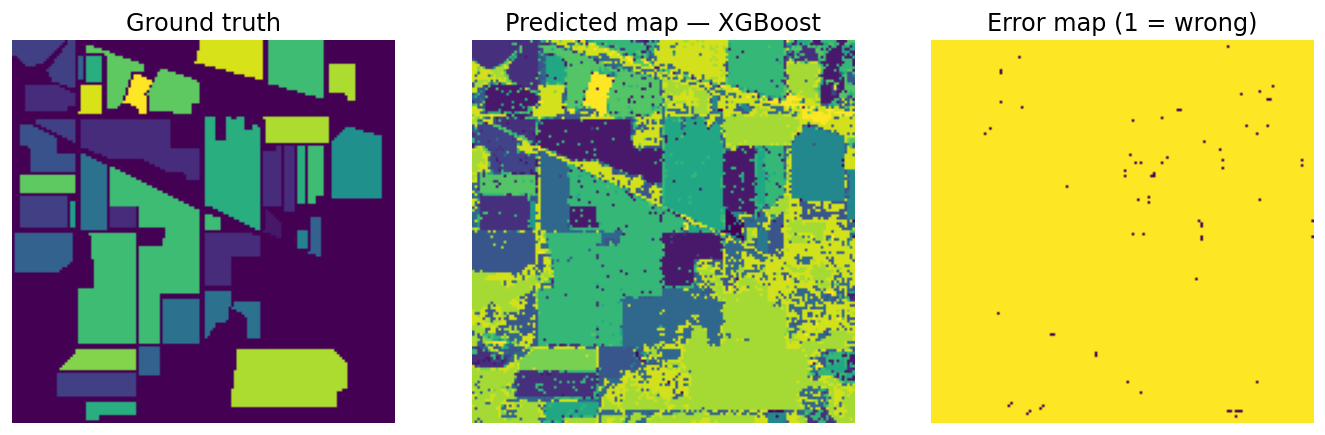

In [ ]:
# Cell 15 — Prediction map (predict all pixels and reshape to HxW) and error map
# Prepare all pixels with same pipeline: scaler -> pca
X_all = X_all if 'X_all' in globals() else X_all  # keep compatibility
X_full = X.reshape(-1, B)
X_full_scaled = scaler.transform(X_full)    # scaler trained on labeled pixels (ok)
X_full_pca = pca.transform(X_full_scaled)
pred_full = best_model.predict(X_full_pca)
pred_map = pred_full.reshape(H, W)

plt.figure(figsize=(14,5))
plt.subplot(1,3,1)
plt.imshow(y)
plt.title("Ground truth")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(pred_map)
plt.title(f"Predicted map — {best_name}")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow((pred_map != y))
plt.title("Error map (1 = wrong)")
plt.axis('off')
plt.show()
